# Regional Ranking with K-Means Clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "COMPETITION_DATA").exists() else Path.cwd().parent
DATA_DIR = REPO_ROOT / "COMPETITION_DATA"
PROCESSED_DIR = REPO_ROOT / "processed_data"
PROCESSED_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)

In [ ]:
team_agg = pd.read_csv(PROCESSED_DIR / "team_agg.csv")
team_regions = pd.read_csv(DATA_DIR / "Team Region Groups - Sheet1.csv")

print(team_agg.shape, team_regions.shape)

## Selecting clustering features

In [60]:
team_agg.drop(columns=['opponent_team_score_mean', 'TOV_mean', 'TOV_team_mean', 'OT_length_min_tot_mean', 'rest_days_mean', 'tz_dif_H_E_mean', 'prev_game_dist_mean', 'travel_dist_mean', 'point_diff_mean', 'region'], inplace=True)

In [61]:
ranking = pd.merge(team_regions, team_agg, on=['team'], how='left')
ranking = ranking[~(ranking['win_percentage'].isna())]

features_to_scale = ['total_wins', 'elo_rating']
scaler = MinMaxScaler(feature_range=(0, 1))
ranking[features_to_scale] = scaler.fit_transform(ranking[features_to_scale])
ranking

,team,region,win_percentage,total_wins,team_score_mean,fg_pct_2_mean,fg_pct_3_mean,ft_pct_mean,AST_mean,BLK_mean,STL_mean,DREB_mean,OREB_mean,F_personal_mean,F_tech_mean,largest_lead_mean,attendance_mean,elo_rating,combined_rank_score
0,alabama_crimson_tide,North,0.566667,0.294118,0.434891,0.467527,0.335122,0.708576,0.283333,0.434958,0.329630,0.417949,0.376042,0.416129,0.020000,0.511084,0.705633,0.250511,0.539751
1,alabama_state_lady_hornets,North,0.481481,0.058824,0.365178,0.406138,0.289688,0.678347,0.344650,0.515411,0.255144,0.420703,0.442130,0.559140,0.051852,0.391858,0.531854,0.000000,0.487752
2,arkansas_razorbacks,North,0.580645,0.352941,0.464878,0.467804,0.323014,0.676956,0.326165,0.571328,0.272401,0.456576,0.346774,0.401665,0.012903,0.507477,0.718469,0.288512,0.548167
3,belmont_bruins,North,0.758621,0.588235,0.425073,0.512895,0.329089,0.692107,0.402299,0.496145,0.330779,0.385500,0.344828,0.344828,0.000000,0.584885,0.579638,0.587705,0.648388
4,charleston_cougars,North,0.535714,0.176471,0.453271,0.446814,0.286593,0.760101,0.345238,0.497138,0.386243,0.379121,0.440848,0.369816,0.014286,0.473581,0.424833,0.134492,0.519918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,ut_arlington_mavericks,West,0.740741,0.470588,0.429560,0.476585,0.272106,0.690607,0.404321,0.477238,0.293553,0.463438,0.335648,0.400239,0.014815,0.533610,0.540811,0.569349,0.638759
135,utah_utes,West,0.645161,0.470588,0.486283,0.494864,0.346593,0.784853,0.396057,0.385041,0.253286,0.425145,0.417339,0.405827,0.064516,0.537464,0.684906,0.453177,0.586608
136,utah_valley_wolverines,West,0.482759,0.117647,0.359974,0.482994,0.301357,0.785739,0.379310,0.365544,0.197957,0.485411,0.325431,0.369299,0.020690,0.468169,0.526116,0.101047,0.492185
137,washington_state_cougars,West,0.655172,0.411765,0.343539,0.425022,0.332651,0.695577,0.342912,0.519461,0.292465,0.381963,0.349138,0.372636,0.034483,0.480665,0.597482,0.435254,0.590940


In [62]:
ranking.columns

Index(['team', 'region', 'win_percentage', 'total_wins', 'team_score_mean',
       'fg_pct_2_mean', 'fg_pct_3_mean', 'ft_pct_mean', 'AST_mean', 'BLK_mean',
       'STL_mean', 'DREB_mean', 'OREB_mean', 'F_personal_mean', 'F_tech_mean',
       'largest_lead_mean', 'attendance_mean', 'elo_rating',
       'combined_rank_score'],
      dtype='object')

## North Region

In [68]:
ranking_north = ranking[ranking['region'] == 'North']

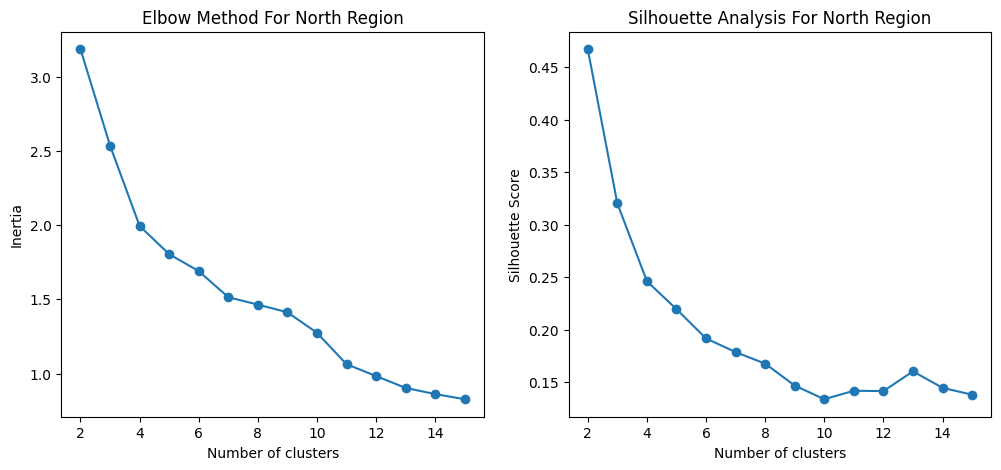

In [65]:
df = ranking_north

features_scaled = df[['win_percentage', 'total_wins', 'team_score_mean',
       'fg_pct_2_mean', 'fg_pct_3_mean', 'ft_pct_mean', 'AST_mean', 'BLK_mean',
       'STL_mean', 'DREB_mean', 'OREB_mean',
       'largest_lead_mean', 'elo_rating',
       'combined_rank_score']]

features = df.drop(columns=['team', 'region'])

inertia = []
silhouette = []
K_range = range(2, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(features_scaled, kmeans.labels_)
    silhouette.append(score)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For North Region')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis For North Region')
plt.show()


In [66]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(features_scaled)
centroids = kmeans.cluster_centers_

# Rank clusters by their centroids
# Sum the centroid values to get a single score per cluster.
cluster_scores = {}
for i in range(n_clusters):
    cluster_scores[i] = np.sum(centroids[i])

# Order clusters from best to worst (highest summed value is best)
sorted_clusters = sorted(cluster_scores.items(), key=lambda x: x[1], reverse=True)
print("Cluster ranking based on centroids (best to worst):")
for rank, (cluster_label, score) in enumerate(sorted_clusters, 1):
    print(f"Rank {rank}: Cluster {cluster_label} with score {score:.2f}")

# Create a mapping from cluster label to overall cluster rank
cluster_order = {cluster_label: rank for rank, (cluster_label, _) in enumerate(sorted_clusters, 1)}
df['cluster_order'] = df['cluster'].map(cluster_order)

# Compute distance of each team (in scaled space) to its cluster centroid
scaled_df = pd.DataFrame(features_scaled)
df['distance'] = [
    np.linalg.norm(scaled_df.iloc[i].values - centroids[cluster])
    for i, cluster in enumerate(df['cluster'])
]

# Within each cluster, rank teams based on distance (lower distance = closer to the centroid)
df['within_cluster_rank'] = df.groupby('cluster')['distance'].rank(method='first', ascending=True)

# Sort teams first by the cluster rank (best clusters first) then by within-cluster ranking
df_sorted = df.sort_values(by=['cluster_order', 'within_cluster_rank'])

print("\nFinal Team Rankings:")
print(df_sorted[['team', 'cluster', 'cluster_order', 'distance', 'within_cluster_rank']])

Cluster ranking based on centroids (best to worst):
Rank 1: Cluster 1 with score 7.71
Rank 2: Cluster 2 with score 6.98
Rank 3: Cluster 3 with score 5.99
Rank 4: Cluster 0 with score 5.42

Final Team Rankings:
                               team  cluster  cluster_order  distance  \
46                      ucf_knights        1              1  0.179738   
39       stephen_f_austin_ladyjacks        1              1  0.197239   
26                       lsu_tigers        1              1  0.211708   
9         florida_gulf_coast_eagles        1              1  0.228877   
37              south_florida_bulls        1              1  0.241220   
35         south_carolina_gamecocks        1              1  0.445773   
31                  ole_miss_rebels        2              2  0.117894   
8                    florida_gators        2              2  0.154463   
5                   charlotte_49ers        2              2  0.158938   
44                tulane_green_wave        2              2 

/tmp/ipython-input-3437717245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = kmeans.fit_predict(features_scaled)
/tmp/ipython-input-3437717245.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster_order'] = df['cluster'].map(cluster_order)
/tmp/ipython-input-3437717245.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

## Visualizing the top two tiers

Teams are placed at their true distance from the centroid. The angle is arbitrary and only
serves to spread the labels out.

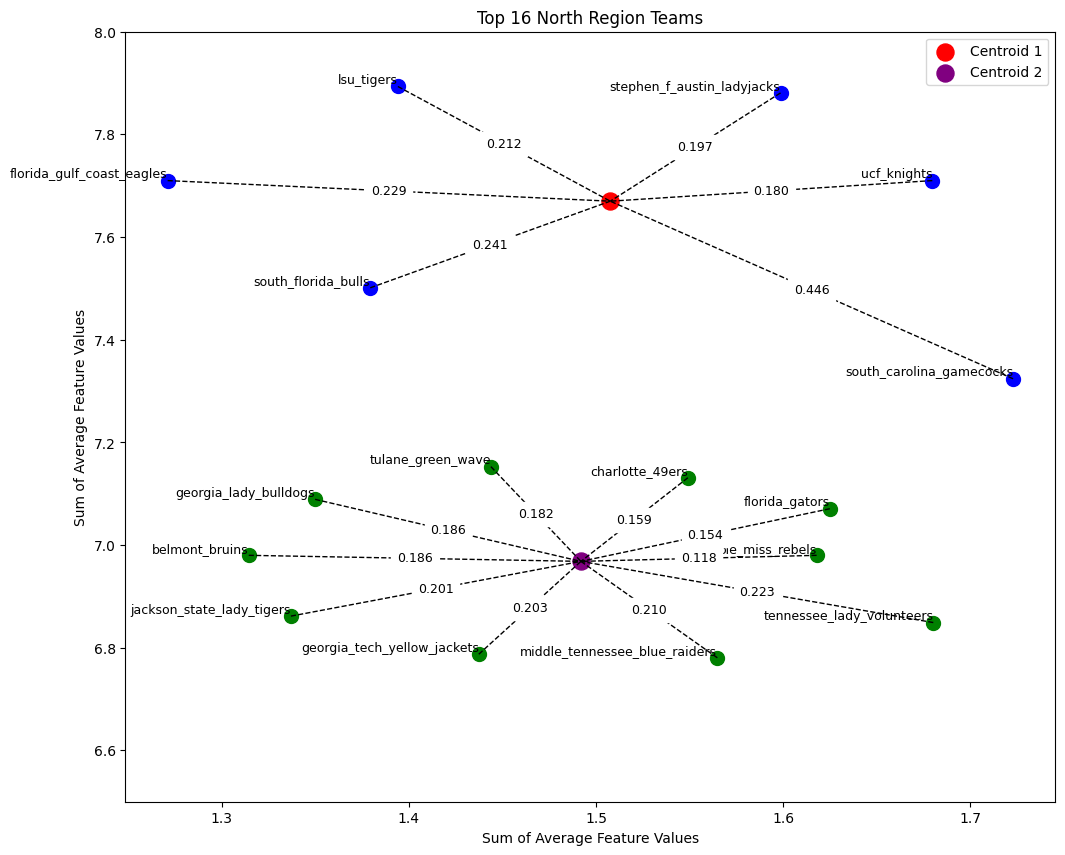

In [67]:
centroid1 = np.array([1.5, 7.71])  # Centroid 1 for cluster 1 with y = 7.71
centroid2 = np.array([1.5, 6.98])  # Centroid 2 for cluster 2 with y = 6.98

cluster1_teams = {
    "ucf_knights": 0.179738,
    "stephen_f_austin_ladyjacks": 0.197239,
    "lsu_tigers": 0.211708,
    "florida_gulf_coast_eagles": 0.228877,
    "south_florida_bulls": 0.241220,
    "south_carolina_gamecocks": 0.445773
}

cluster2_teams = {
    "ole_miss_rebels": 0.117894,
    "florida_gators": 0.154463,
    "charlotte_49ers": 0.158938,
    "tulane_green_wave": 0.181696,
    "georgia_lady_bulldogs": 0.185529,
    "belmont_bruins": 0.185529,
    "jackson_state_lady_tigers": 0.201486,
    "georgia_tech_yellow_jackets": 0.202629,
    "middle_tennessee_blue_raiders": 0.209884,
    "tennessee_lady_volunteers": 0.222797
}

# Function to generate approximate 2D coordinates around a centroid using distance and random angle
def generate_points_around_centroid(centroid, distances, num_points):
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    points = []
    for i, (team, dist) in enumerate(distances.items()):
        x = centroid[0] + dist * np.cos(angles[i % len(angles)])
        y = centroid[1] + dist * np.sin(angles[i % len(angles)])
        points.append((team, np.array([x, y]), dist))
    return points

# Generate points for clusters
cluster1_points = generate_points_around_centroid(centroid1, cluster1_teams, len(cluster1_teams))
cluster2_points = generate_points_around_centroid(centroid2, cluster2_teams, len(cluster2_teams))

# Extract coordinates and team names
cluster1_coords = np.array([pt[1] for pt in cluster1_points])
cluster1_names = [pt[0] for pt in cluster1_points]
cluster1_distances = [pt[2] for pt in cluster1_points]

cluster2_coords = np.array([pt[1] for pt in cluster2_points])
cluster2_names = [pt[0] for pt in cluster2_points]
cluster2_distances = [pt[2] for pt in cluster2_points]

# Compute centroids
centroid1_actual = np.mean(cluster1_coords, axis=0)
centroid2_actual = np.mean(cluster2_coords, axis=0)

# Plot the data points for clusters with team names as labels
plt.figure(figsize=(12, 10))
for (x, y), name, dist in zip(cluster1_coords, cluster1_names, cluster1_distances):
    plt.scatter(x, y, color='blue', s=100)
    plt.text(x, y, name, fontsize=9, ha='right', va='bottom')
    plt.plot([x, centroid1_actual[0]], [y, centroid1_actual[1]], 'k--', lw=1)
    plt.text((x + centroid1_actual[0]) / 2, (y + centroid1_actual[1]) / 2, f"{dist:.3f}", fontsize=9, ha='center', va='center', backgroundcolor='white')

for (x, y), name, dist in zip(cluster2_coords, cluster2_names, cluster2_distances):
    plt.scatter(x, y, color='green', s=100)
    plt.text(x, y, name, fontsize=9, ha='right', va='bottom')
    plt.plot([x, centroid2_actual[0]], [y, centroid2_actual[1]], 'k--', lw=1)
    plt.text((x + centroid2_actual[0]) / 2, (y + centroid2_actual[1]) / 2, f"{dist:.3f}", fontsize=9, ha='center', va='center', backgroundcolor='white')

# Plot the centroids
plt.scatter([centroid1_actual[0]], [centroid1_actual[1]], color='red', label='Centroid 1', s=150)
plt.scatter([centroid2_actual[0]], [centroid2_actual[1]], color='purple', label='Centroid 2', s=150)

plt.xlabel('Sum of Average Feature Values')
plt.ylabel('Sum of Average Feature Values')
plt.title('Top 16 North Region Teams')
plt.legend()
plt.grid(False)
plt.ylim(6.5, 8)
plt.show()
